# Rising Bubble PINN: обучение по этапам

Ноутбук запускает тот же PyTorch pipeline, что и `train_rising_bubble.py`, но по отдельным этапам. После каждой ячейки этапа можно смотреть loss, checkpoints и графики истории.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch

cwd = Path.cwd().resolve()
PROJECT_DIR = cwd if (cwd / "pinn").exists() else cwd / "diploma"
ROOT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from pinn.config import preset_config
from pinn.train import TrainingRun, resolve_device

print("project:", PROJECT_DIR)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

project: /Users/erklyavlin/repos/diploma/diploma
torch: 2.11.0
cuda available: False


## 1. Конфигурация

`smoke` нужен для быстрой проверки. Для рабочего запуска поменяй `preset_name` на `default`; для максимально близкого к статье запуска - на `paper`.

In [2]:
preset_name = "paper_light"  # smoke | default | paper
cfg = preset_config(preset_name)

# cfg.data_path = ROOT_DIR / "diploma" / "cfd_data" / "rising_bubble.h5"
cfg.data_path = ROOT_DIR / "diploma" / "exp" / "train"
cfg.output_dir = PROJECT_DIR / "checkpoints"
cfg.device = "auto"  # auto | cpu | cuda | cuda:0
cfg.dtype = "float32"

# Примеры точечной настройки без CLI:
# cfg.epochs = (500, 500, 500)
# cfg.learning_rates = (1e-4, 5e-5, 1e-5)
# cfg.hidden_layers = (128, 128, 128, 128)
# cfg.batch_size = 4096  # ручной total batch size
# cfg.batch_size = None; cfg.num_batches = 20  # как у авторов: ceil(total_points / 20)

assert cfg.data_path.exists(), f"Не найден файл данных: {cfg.data_path}"
assert len(cfg.epochs) == len(cfg.learning_rates)

cfg.to_dict()

{'data_path': '/Users/erklyavlin/repos/diploma/diploma/exp/train',
 'output_dir': '/Users/erklyavlin/repos/diploma/diploma/checkpoints',
 'hidden_layers': (32, 64, 128, 256, 128, 64, 32),
 'activation': 'tanh',
 'points': {'alpha': (500, 400),
  'pde': (400, 2000, 3000),
  'north': (20, 20),
  'south': (20, 20),
  'east': (20, 20),
  'west': (20, 20)},
 'physics': {'mu': (1.0, 10.0),
  'rho': (100.0, 1000.0),
  'sigma': 24.5,
  'g': -0.98,
  'u_ref': 1.0,
  'l_ref': 0.25,
  'p_ref_rho': 1000.0},
 'loss_weights_pde': (1.0, 10.0, 10.0, 1.0),
 'epochs': (5000, 5000, 5000, 5000, 5000),
 'learning_rates': (0.0001, 5e-05, 1e-05, 5e-06, 1e-06),
 'batch_size': None,
 'num_batches': 20,
 'checkpoint_interval': 100,
 'seed': 1234,
 'device': 'auto',
 'dtype': 'float32',
 'num_workers': 0}

## 2. Создание training run

Эта ячейка загружает и сэмплирует данные, создает модель, optimizer и папку запуска в `diploma/checkpoints/<timestamp>`.

In [3]:
run = TrainingRun(cfg)
run.run_dir

Loading and sampling training data from /Users/erklyavlin/repos/diploma/diploma/exp/train
Training point counts: {'alpha': 130500, 'pde': 791000, 'north': 2000, 'east_west': 2000, 'nsew': 4200}
Device: cpu, dtype: torch.float32, total batch size: 46485, batches/epoch: 20, batch sizes: {'alpha': 6525, 'pde': 39550, 'north': 100, 'east_west': 100, 'nsew': 210}


PosixPath('/Users/erklyavlin/repos/diploma/diploma/checkpoints/20260511_130548')

In [4]:
def history_frame(run):
    if not run.history:
        return pd.DataFrame()
    return pd.DataFrame(run.history)


def plot_losses(run, keys=("total", "alpha", "continuity", "momentum_x", "momentum_y")):
    df = history_frame(run)
    if df.empty:
        print("История пока пустая.")
        return df
    available = [key for key in keys if key in df.columns]
    ax = df.plot(x="epoch", y=available, logy=True, figsize=(10, 5), grid=True)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Training losses")
    plt.show()
    return df.tail()


def checkpoint_files(run):
    return sorted(path.name for path in run.run_dir.glob("*.pt"))

## 3. Этап 1

In [5]:
stage = 1
run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

stage 1 lr=0.0001:   0%|          | 0/5000 [00:21<?, ?it/s]


KeyboardInterrupt: 

## 4. Этап 2

Запускай эту ячейку, если в конфигурации есть второй этап.

stage 2 lr=5e-05: 100%|██████████| 5000/5000 [1:00:47<00:00,  1.37it/s, alpha=5.54e-03, pde_u=2.41e-04, total=1.157e-02]


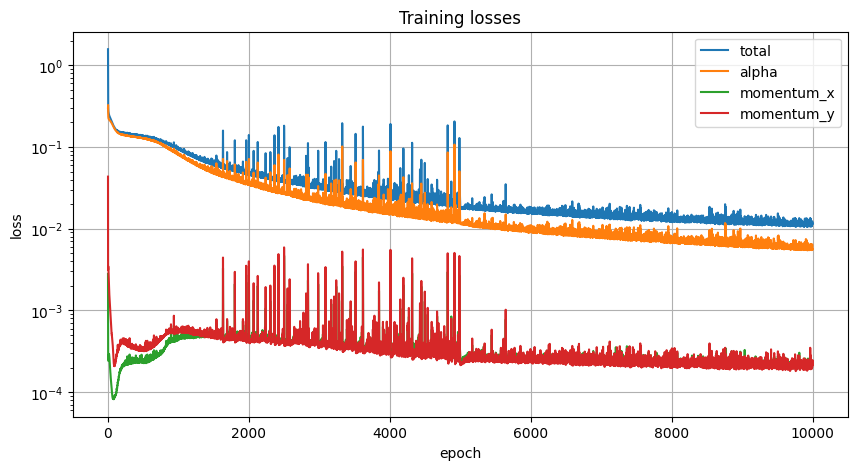

['best.pt',
 'epoch_000100.pt',
 'epoch_000200.pt',
 'epoch_000300.pt',
 'epoch_000400.pt',
 'epoch_000500.pt',
 'epoch_000600.pt',
 'epoch_000700.pt',
 'epoch_000800.pt',
 'epoch_000900.pt',
 'epoch_001000.pt',
 'epoch_001100.pt',
 'epoch_001200.pt',
 'epoch_001300.pt',
 'epoch_001400.pt',
 'epoch_001500.pt',
 'epoch_001600.pt',
 'epoch_001700.pt',
 'epoch_001800.pt',
 'epoch_001900.pt',
 'epoch_002000.pt',
 'epoch_002100.pt',
 'epoch_002200.pt',
 'epoch_002300.pt',
 'epoch_002400.pt',
 'epoch_002500.pt',
 'epoch_002600.pt',
 'epoch_002700.pt',
 'epoch_002800.pt',
 'epoch_002900.pt',
 'epoch_003000.pt',
 'epoch_003100.pt',
 'epoch_003200.pt',
 'epoch_003300.pt',
 'epoch_003400.pt',
 'epoch_003500.pt',
 'epoch_003600.pt',
 'epoch_003700.pt',
 'epoch_003800.pt',
 'epoch_003900.pt',
 'epoch_004000.pt',
 'epoch_004100.pt',
 'epoch_004200.pt',
 'epoch_004300.pt',
 'epoch_004400.pt',
 'epoch_004500.pt',
 'epoch_004600.pt',
 'epoch_004700.pt',
 'epoch_004800.pt',
 'epoch_004900.pt',
 'epoch_

In [6]:
stage = 2
if stage <= len(cfg.epochs):
    run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

## 5. Этап 3

Запускай эту ячейку, если в конфигурации есть третий этап.

In [ ]:
stage = 3
if stage <= len(cfg.epochs):
    run.train_stage(stage=stage)
plot_losses(run)
checkpoint_files(run)

stage 3 lr=1e-05:  64%|██████▍   | 3194/5000 [38:46<21:41,  1.39it/s, alpha=4.66e-03, pde_u=1.87e-04, total=9.465e-03] 

## 6. Дополнительный этап

Можно продолжить обучение с другой скоростью обучения, не меняя checkpoint вручную.

In [ ]:
# run.train_stage(epochs=200, lr=5e-6, stage=run.current_stage + 1)
# plot_losses(run)
# checkpoint_files(run)

## 7. История и checkpoints

In [ ]:
history_path = run.run_dir / "history.json"
config_path = run.run_dir / "config.json"

print("run_dir:", run.run_dir)
print("best:", run.run_dir / "best.pt")
print("last:", run.run_dir / "last.pt")
print("history:", history_path)

history_frame(run).tail(10)

## 8. Визуализация предсказаний

Сравнение полей CFD и PINN на регулярной сетке: истинное значение, предсказание и ошибка. Для ускорения можно увеличить `spatial_step`.

In [10]:
from pinn.visualize import align_pressure_gauge, error_metrics, plot_centerline, plot_field_comparison, predict_cfd_grid

# Если ноутбук был открыт заново и переменной run нет, укажи checkpoint вручную:
# checkpoint_path = PROJECT_DIR / "checkpoints" / "20260504_101454" / "best.pt"
# checkpoint_path = run.run_dir / "best.pt"
checkpoint_path = "D:/diploma_jupyter/diploma/checkpoints/20260504_110505" + "/best.pt"
data_path = cfg.data_path

pred, true, coords = predict_cfd_grid(
    checkpoint_path=checkpoint_path,
    data_path=data_path,
    device=cfg.device,
    start=0,
    end=151,
    temporal_step=10,
    spatial_step=4,
)

pred_aligned = align_pressure_gauge(pred, true)

print("prediction shapes:", {name: value.shape for name, value in pred.items()})
error_metrics(pred_aligned, true)

prediction shapes: {'u': (16, 128, 64), 'v': (16, 128, 64), 'p': (16, 128, 64), 'alpha': (16, 128, 64)}


,field,rmse,mae,relative_rmse,pred_min,pred_max,true_min,true_max
0,u,0.009154,0.005827,0.152372,-2.467981e-01,0.240501,-0.244321,0.244941
1,v,0.017797,0.012449,0.132309,-4.918956e-01,0.396758,-0.521869,0.432804
2,p,0.057456,0.030214,0.009595,5.076621e+00,6.862026,5.040214,6.998086
3,alpha,0.025158,0.002152,0.078915,1.626591e-07,0.999996,0.000000,1.000000


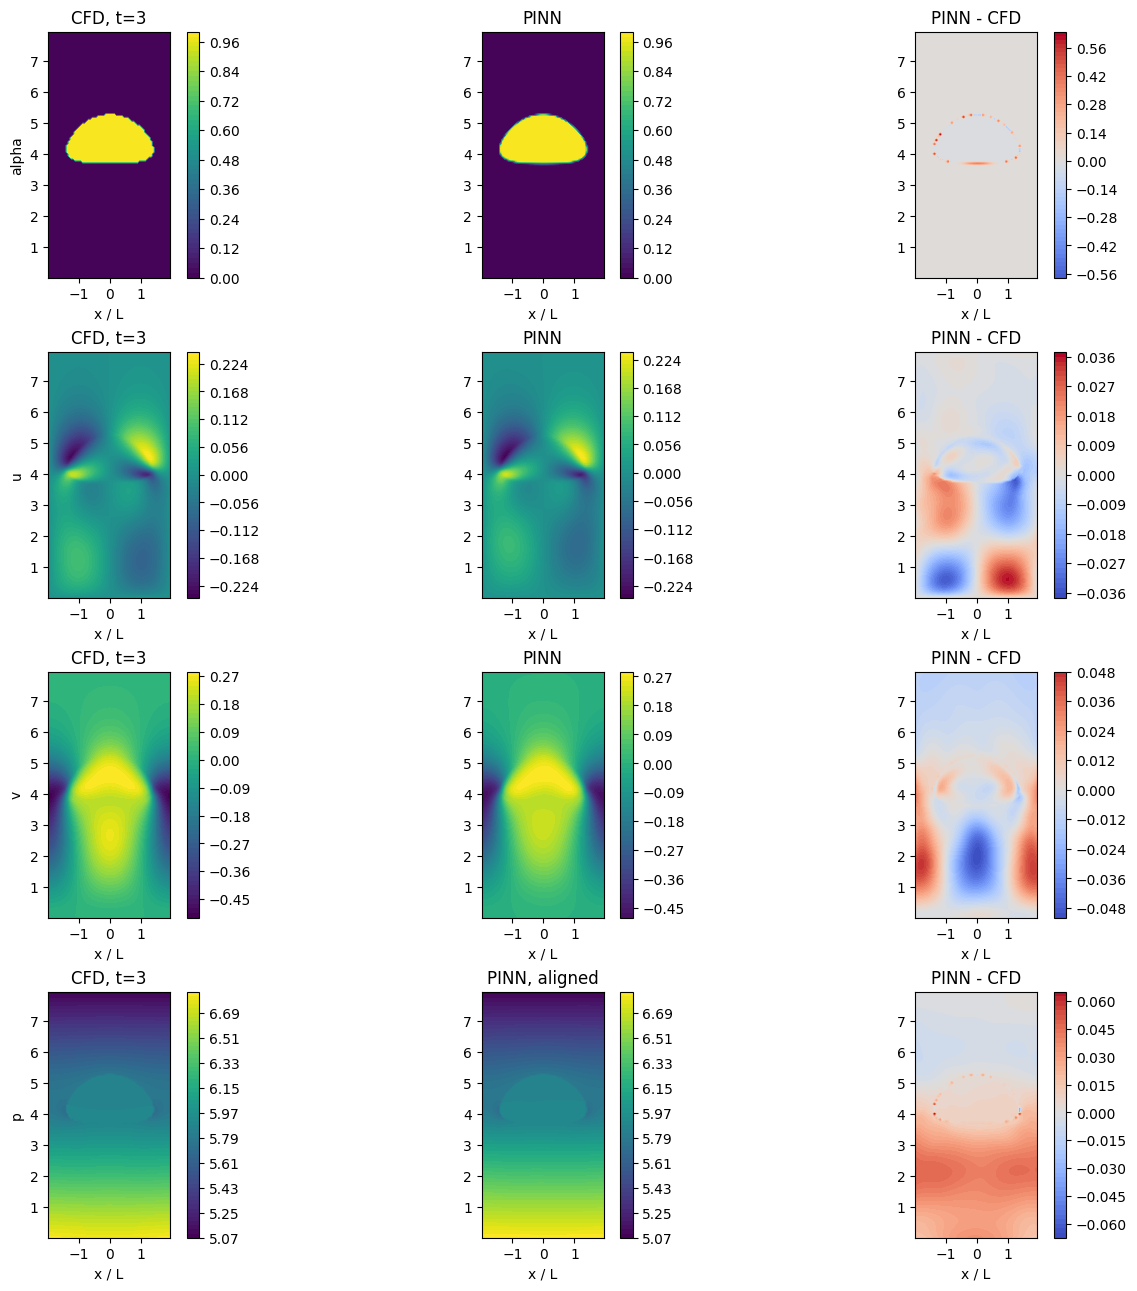

In [11]:
time_index = -1  # -1 = последний выбранный временной слой
fig = plot_field_comparison(
    pred,
    true,
    coords,
    time_index=time_index,
    fields=("alpha", "u", "v", "p"),
    save_path=run.run_dir / f"comparison_t{time_index}.png",
)

In [ ]:
# Вертикальный профиль через центр домена. Удобно смотреть alpha, u, v или p.
plot_centerline(pred, true, coords, field="alpha", time_index=time_index, x_value=0.0);

/Users/erklyavlin/repos/diploma/diploma/cfd_data/rising_bubble_basilisk_r030.h5 | layer -1 -> 150 | t = 3.00009


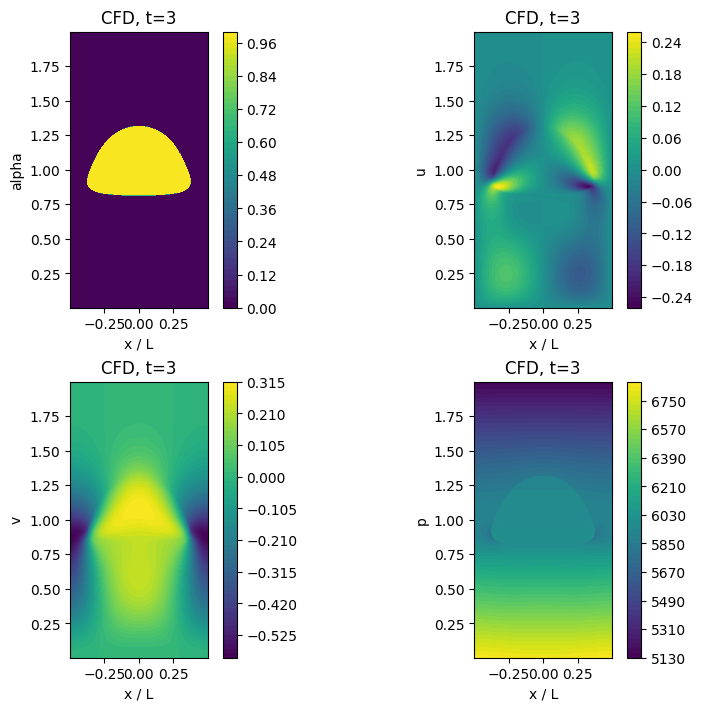

In [7]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

# Укажи путь до нужного .h5 файла и номер временного слоя.
h5_path = Path("cfd_data/rising_bubble_basilisk_r030.h5")
time_layer = -1  # можно использовать отрицательные индексы, например -1
spatial_step = 1  # увеличь, если файл большой и отрисовка тормозит

if not h5_path.is_absolute():
    base_dir = PROJECT_DIR if "PROJECT_DIR" in globals() else Path.cwd()
    h5_path = base_dir / h5_path

with h5py.File(h5_path, "r") as h5:
    required = ("velocityX", "velocityY", "pressure")
    missing = [name for name in required if name not in h5]
    if missing:
        raise KeyError(f"В файле нет датасетов: {missing}. Доступные ключи: {list(h5.keys())}")

    n_times = h5["pressure"].shape[0]
    t_idx = time_layer if time_layer >= 0 else n_times + time_layer
    if not 0 <= t_idx < n_times:
        raise IndexError(f"time_layer={time_layer} вне диапазона [{-n_times}, {n_times - 1}]")

    step = max(1, int(spatial_step))
    ux = h5["velocityX"][t_idx, ::step, ::step].T
    uy = h5["velocityY"][t_idx, ::step, ::step].T
    pressure = h5["pressure"][t_idx, ::step, ::step].T
    alpha = (h5["levelset"][t_idx, ::step, ::step].T < 0.0).astype(float) if "levelset" in h5 else None
    time_value = h5["time"][t_idx] if "time" in h5 else None

    x_key = "X" if "X" in h5 else "x"
    y_key = "Y" if "Y" in h5 else "y"
    x = h5[x_key][::step] if x_key in h5 else np.arange(pressure.shape[1])
    y = h5[y_key][::step] if y_key in h5 else np.arange(pressure.shape[0])

l_ref = cfg.physics.l_ref if "cfg" in globals() else 1.0
x = x / l_ref
y = y / l_ref

plots = []
if alpha is not None:
    plots.append((alpha, "alpha"))
plots.extend([(ux, "u"), (uy, "v"), (pressure, "p")])

fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=True)
axes = axes.ravel()
title_time = float(time_value) if time_value is not None else t_idx

for ax, (field, ylabel) in zip(axes, plots):
    im = ax.contourf(x, y, field, levels=60, cmap="viridis")
    ax.set_title(f"CFD, t={title_time:.4g}")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("x / L")
    ax.set_aspect("equal")
    fig.colorbar(im, ax=ax)

for ax in axes[len(plots):]:
    ax.axis("off")

label = f"{h5_path} | layer {time_layer} -> {t_idx}"
if time_value is not None:
    label += f" | t = {float(time_value):.6g}"
print(label)
plt.show()
